# Milestone 2 - Analisis Pergerakan Harga Bitcoin (2021-2026)

**Link Dashboard Tableau:** https://public.tableau.com/views/P1M2_yohanes-bos/DashboardAnalisisHargaBitcoin20212026?:language=en-US&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link 

## 1. Perkenalan

Nama    : Yohanes Bos

Program : Hacktiv8 Comprehensive Data Analytics Program - Phase 1

Milestones 2

Pada Notebook ini, saya berperan sebagai Data Analyst yang mengerjakan proyek analisis data harga Bitcoin untuk membantu client memahami pergerakan harga, tingkat risiko, dan karakteristik pasar Bitcoin selama beberapa tahun terakhir.

## 2. Identifikasi masalah

### Topik Permasalahan
Analisis pergerakan Harga dan volatilitas Bitcoin dalam kurun waktu Januari 2021 sampai Juni 2026

### Latar Belakang
Bitcoin adalah asset kripto dengan kapitalisasi pasar terbesar di dunia. Harganya sangat fluktuatif, sehingga banyak investor dan trader kesulitan menentukan kapan waktu yang baik untuk masuk atau keluar pasar. Client kami adalah sebuah **firma investasi ritel** yang ingin memahami karakteristik pergerakan harga Bitcoin secara historis agar dapat Menyusun strategi manajemen risiko yang lebih baik bagi nasabahnya.

### Problem Statement (Metode SMART)
Menganalisis pola pergerakan harga harian dan tingkat volatilitas Bitcoin selama periode 1 Januari 2021 sampai 1 Juni 2026 untuk membantu firma investasi memahami tren tahunan, mengukur risiko harian, dan mengidentifikasi karakteristik perubahan harga sebagai perubahan dasar penyusunan strategi investasi.

Penjelasan SMART:
- **Specific:** Menganalisis pola pergerakan harga harian dan tingkat volatilitas Bitcoin selama periode 1 Januari 2021 sampai 1 Juni 2026.
- **Measurable:** Diukur lewat harga rata-rata, persentase perubahan harian, standar deviasi, dan rentang harga (High-Low).
- **Achievable:** Data harian lengkap tersedia, dapat diolah dengan statistik dan visualisasi.
- **Relevant:** Sesuai kebutuhan firma investasi untuk manajemen risiko.
- **Time-bound:** Data yang dianalisis mencakup periode Januari 2021 - Juni 2026. Adapun hasil analisis ini ditargetkan dapat diimplementasikan oleh firma investasi mulai Kuartal 3 tahun 2026 (Juli 2026), yaitu setelah laporan dipresentasikan dan disetujui, untuk digunakan sebagai dasar penyusunan strategi investasi dan manajemen risiko pada periode berikutnya.

### Rangkuman Problem Statement (SMART)
> Menganalisis pola pergerakan harga harian dan tingkat volatilitas Bitcoin yang diukur melalui harga rata-rata, persentase perubahan harian, standar deviasi, dan rentang harga, menggunakan data harian lengkap yang dapat diolah dengan statistik dan visualisasi, guna membantu firma investasi dalam manajemen risiko, berdasarkan data periode Januari 2021 - Juni 2026 dan ditargetkan dapat diimplementasikan mulai Kuartal 3 tahun 2026.

### Penjabaran Masalah (Metode 5W+1H)
Saya menyusun 6 penjabaran masalah, dengan 4 untuk visualisasi data, 1 untuk statistic deskriptif, dan 1 untuk statistic inferensial.

**Visualisasi Data:**
1. **(What/When)** Bagaimana tren harga penutupan Bitcoin dari waktu ke waktu (2021-2026)?
2. **(How)** Berapa rata-rata harga Bitcoin di tiap tahun, dan tahun mana yang paling tinggi?
3. **(How)** Bagaimana sebaran (distribusi) persentase perubahan harga harian Bitcoin?
4. **(What)** Apakah volume perdagangan berhubungan dengan besarnya perubahan harga harian?

**Statistik Deskriptif:** 

5. **(How)** Seberapa besar volatilitas (risiko) harian Bitcoin diukur dari central tendency dan measure of variance perubahan harga harian?

**Statistik Inferensial:** 

6. **(Why)** Apakah rata-rata perubahan harga harian Bitcoin pada tahun 2025 (bull market) berbeda secara signifikan dibandingkan tahun 2022 (bear market)?


## 3. Data Loading
Dataset diunduh dari Investing.com - Bitcoin Historical Data yang berisi data harga harian Bitcoin (BTC/USD).

**Referensi sumber data:** https://www.investing.com/crypto/bitcoin/historical-data

>Dataset di atas berformat CSV, sehingga proses loading dilakukan dengan pandas (tidak menggunakan SQL/BigQuery).


In [1]:
# Import Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Pengaturan tampilan
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

In [2]:
# Load dataset
df = pd.read_csv("C:\Milestones\m2\Bitcoin Historical Data.csv")

# Lihat 5 baris pertama
df.head()

<>:2: SyntaxWarning: invalid escape sequence '\M'
<>:2: SyntaxWarning: invalid escape sequence '\M'
C:\Users\hp5cd\AppData\Local\Temp\ipykernel_35584\1378944612.py:2: SyntaxWarning: invalid escape sequence '\M'
  df = pd.read_csv("C:\Milestones\m2\Bitcoin Historical Data.csv")


,Date,Price,Open,High,Low,Vol.,Change %
0,06/01/2026,"71,398.8","73,661.9","74,045.7","70,680.8",77.46K,-3.07%
1,05/31/2026,"73,658.9","73,848.0","74,256.7","73,409.9",27.95K,-0.26%
2,05/30/2026,"73,847.9","73,455.8","74,112.6","73,210.6",33.11K,0.54%
3,05/29/2026,"73,448.9","73,710.3","74,307.5","72,531.5",64.38K,-0.21%
4,05/28/2026,"73,605.9","74,496.7","74,569.6","72,592.2",72.18K,-1.11%


In [3]:
# Lihat ukuran data (jumlah baris dan kolom)
print('Jumlah baris:', df.shape[0])
print('Jumlah kolom:', df.shape[1])

Jumlah baris: 1978
Jumlah kolom: 7


In [4]:
# Cek informasi tipe data tiap kolom
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1978 entries, 0 to 1977
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Date      1978 non-null   str  
 1   Price     1978 non-null   str  
 2   Open      1978 non-null   str  
 3   High      1978 non-null   str  
 4   Low       1978 non-null   str  
 5   Vol.      1978 non-null   str  
 6   Change %  1978 non-null   str  
dtypes: str(7)
memory usage: 108.3 KB


Dari hasil di atas terlihat bahwa hampir semua kolom masih bertipe `object` (teks). Padahal kolom harga seharusnya berupa angka. Hal ini karena angka-angkanya masih mengandung tanda koma, persen, dan satuan seperti "K". Langkah selanjutnya, ke proses cleaning.

## 4. Data Cleaning
Pada bagian ini akan dilakukan beberapa hal, antara lain:
1. Mengubah kolom `Date` menjadi format tanggal.
2. Membersihkan kolom harga (`Price`, `Open`, `High`, `Low`) dari tanda koma dan mengubahnya ke angka.
3. Mengubah kolom `Vol.` (volume) yang mengandung satuan K/M/B menjadi angka penuh.
4. Membersihkan kolom `Change %` menjadi angka.
5. Memberi nama kolom yang lebih rapi.
6. Mengurutkan data berdasarkan tanggal dan mengecek missing values serta duplikat.




In [5]:
# Buat salinan agar data asli tetap aman
data = df.copy()

# 1. Ubah kolom Date menjadi format datetime
data['Date'] = pd.to_datetime(data['Date'])

# 2. Bersihkan kolom harga: hapus koma lalu ubah ke float
kolom_harga = ['Price', 'Open', 'High', 'Low']
for kolom in kolom_harga:
    data[kolom] = data[kolom].str.replace(',', '').astype(float)

data.head()

,Date,Price,Open,High,Low,Vol.,Change %
0,2026-06-01,71398.80,73661.90,74045.70,70680.80,77.46K,-3.07%
1,2026-05-31,73658.90,73848.00,74256.70,73409.90,27.95K,-0.26%
2,2026-05-30,73847.90,73455.80,74112.60,73210.60,33.11K,0.54%
3,2026-05-29,73448.90,73710.30,74307.50,72531.50,64.38K,-0.21%
4,2026-05-28,73605.90,74496.70,74569.60,72592.20,72.18K,-1.11%


In [6]:
# 3. Ubah kolom Volume (Vol.) menjadi angka penuh
# Contoh: '77.46K' -> 77460 ; '1.04B' -> 1.040.000.000
def ubah_volume(nilai):
    nilai = str(nilai).strip()
    if nilai in ['', '-', 'nan']:
        return np.nan
    pengali = 1
    if nilai.endswith('K'):
        pengali = 1_000
        nilai = nilai[:-1]
    elif nilai.endswith('M'):
        pengali = 1_000_000
        nilai = nilai[:-1]
    elif nilai.endswith('B'):
        pengali = 1_000_000_000
        nilai = nilai[:-1]
    return float(nilai) * pengali

data['Volume'] = data['Vol.'].apply(ubah_volume)

# 4. Bersihkan kolom Change % menjadi angka
data['Change'] = data['Change %'].str.replace('%', '').astype(float)

data[['Date', 'Price', 'Volume', 'Change']].head()

,Date,Price,Volume,Change
0,2026-06-01,71398.80,77460.00,-3.07
1,2026-05-31,73658.90,27950.00,-0.26
2,2026-05-30,73847.90,33110.00,0.54
3,2026-05-29,73448.90,64380.00,-0.21
4,2026-05-28,73605.90,72180.00,-1.11


In [7]:
# 5. Rapikan: hapus kolom lama yang sudah diganti, lalu urutkan dari tanggal terlama
data = data.drop(columns=['Vol.', 'Change %'])
data = data.sort_values('Date').reset_index(drop=True)

# Tambahkan kolom bantu Tahun untuk analisis per tahun
data['Year'] = data['Date'].dt.year

data.head()

,Date,Price,Open,High,Low,Volume,Change,Year
0,2021-01-01,29359.90,28951.70,29627.10,28712.40,100900.00,1.42,2021
1,2021-01-02,32193.30,29359.70,33233.50,29008.00,240870.00,9.65,2021
2,2021-01-03,32958.90,32192.90,34755.90,32029.60,155210.00,2.38,2021
3,2021-01-04,32022.60,33016.60,33587.50,28204.50,255270.00,-2.84,2021
4,2021-01-05,33991.50,32015.40,34414.70,30010.50,202130.00,6.15,2021


In [8]:
# 6a. Cek missing values di tiap kolom
print('Jumlah missing value per kolom:')
print(data.isna().sum())

Jumlah missing value per kolom:
Date      0
Price     0
Open      0
High      0
Low       0
Volume    0
Change    0
Year      0
dtype: int64


In [9]:
# 6b. Cek apakah ada baris duplikat
print('Jumlah baris duplikat:', data.duplicated().sum())

Jumlah baris duplikat: 0


Hasilnya menunjukan bahwa data sudah bersih, tidak ada missing value, dan tidak ada duplikat. Tipe data juga sudah benar (tanggal dan angka), sehingga data siap untuk dianalisis.


In [10]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1978 entries, 0 to 1977
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    1978 non-null   datetime64[us]
 1   Price   1978 non-null   float64       
 2   Open    1978 non-null   float64       
 3   High    1978 non-null   float64       
 4   Low     1978 non-null   float64       
 5   Volume  1978 non-null   float64       
 6   Change  1978 non-null   float64       
 7   Year    1978 non-null   int32         
dtypes: datetime64[us](1), float64(6), int32(1)
memory usage: 116.0 KB


### Ekspor data bersih untuk Tableau

In [11]:
data.to_csv('bitcoin_clean.csv', index=False)
print('File bitcoin_clean.csv', data.shape[0], 'baris.')

File bitcoin_clean.csv 1978 baris.


## 5. Analisis dan Perhitungan
Bagian ini berisi visualisasi data, statistik desktiptif, dan statistik inferensial.


### Visualisasi 1 - Tren Harga Bitcoin dari waktu ke waktu 
*Menjawab penjabaran masalah no.1: Bagaimana tren harga penutupan Bitcoin (2021-2026)?*

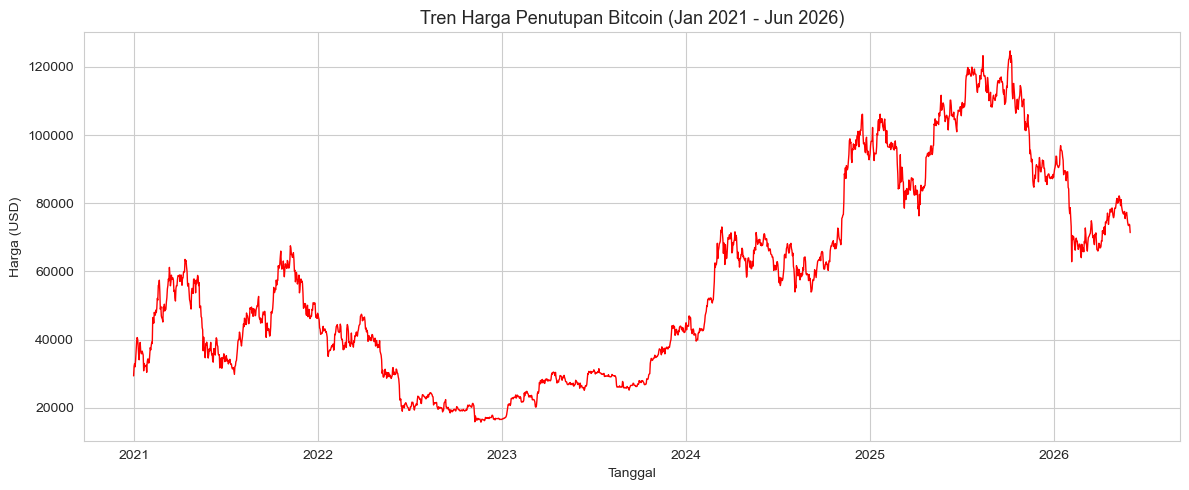

In [12]:
plt.figure(figsize=(12, 5))
plt.plot(data['Date'], data['Price'], color='#FF0000', linewidth=1)
plt.title('Tren Harga Penutupan Bitcoin (Jan 2021 - Jun 2026)', fontsize=13)
plt.xlabel('Tanggal')
plt.ylabel('Harga (USD)')
plt.tight_layout()
plt.show()

In [13]:
# Cari harga tertinggi dan terendah beserta tanggalnya
tertinggi = data.loc[data['Price'].idxmax()]
terendah = data.loc[data['Price'].idxmin()]
print('Harga terendah: $%s' % format(round(terendah['Price']), ','))
print('Harga tertinggi: $%s' % format(round(tertinggi['Price']), ','))

Harga terendah: $15,776
Harga tertinggi: $124,725


**Insight:** Harga Bitcoin bergerak sangat fluktuatif. Terlihat ada periode kenaikan tajam (bull market) dan penurunan dalam (bear market). Harganya sempat jatuh pada tahun 2022, namun kemudian mengalami pelonjakan yang signifikan menuju puncaknya. Pola naik-turun yang ekstrem ini menunjukkan bahwa Bitcoin adalah aset berisiko tinggi, sehingga client perlu strategi manajemen risiko yang ketat.

### Visualisasi 2 - Rata-Rata Harga Bitcoin per Tahun
*Menjawab penjabaran masalah no.2: Berapa rata-rata harga di tiap tahun, dan tahun mana yang paling tinggi?*

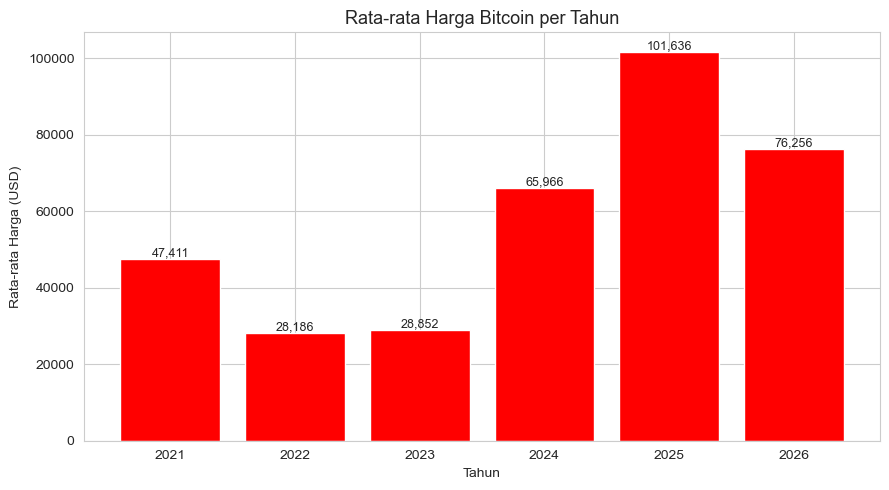

Year
2021    47410.84
2022    28185.67
2023    28851.70
2024    65965.72
2025   101636.18
2026    76256.18
Name: Price, dtype: float64


In [14]:
# Hitung rata-rata harga per tahun
rata_tahun = data.groupby('Year')['Price'].mean()

plt.figure(figsize=(9, 5))
bars = plt.bar(rata_tahun.index.astype(str), rata_tahun.values, color='#FF0000')
plt.title('Rata-rata Harga Bitcoin per Tahun', fontsize=13)
plt.xlabel('Tahun')
plt.ylabel('Rata-rata Harga (USD)')
# Tambahkan label angka di atas tiap batang
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             '{:,.0f}'.format(bar.get_height()), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

print(rata_tahun)

**Insight:** Rata-rata harga tahunan menunjukkan tren menarik. Setelah turun dari 2021 ke 2022, harga kembali menguat dan mencapai puncak rata-rata tertinggi pada tahun **2025** (sekitar USD 101.000). Ini menunjukan bahwa tahun 2025 adalah tahun bull market terkuat dalam periode data.

### Visualisasi 3 - Distribusi Persentase Perubahan Harga Harian 
*Menjawab penjabaran masalah no.3: Bagaimana sebaran perubahan harga harian Bitcoin?*

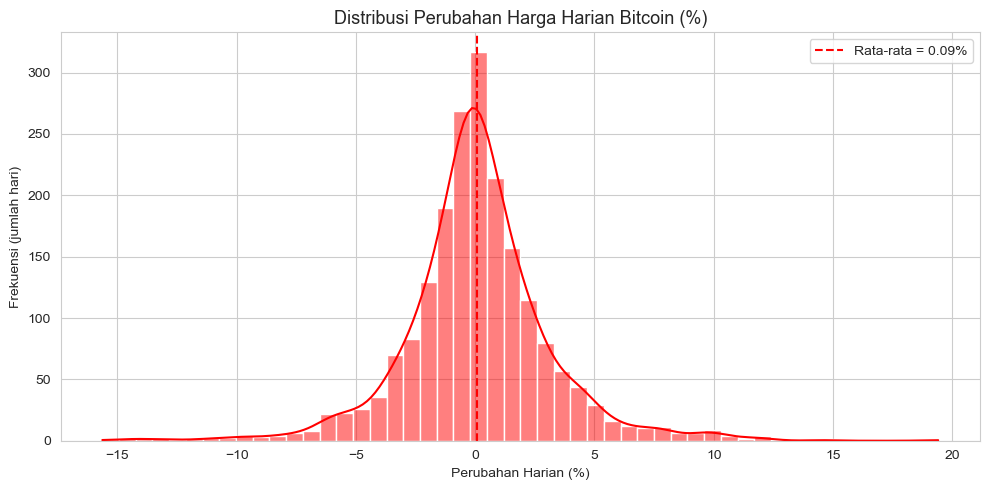

In [15]:
plt.figure(figsize=(10, 5))
sns.histplot(data['Change'], bins=50, kde=True, color='#FF0000')
plt.axvline(data['Change'].mean(), color='red', linestyle='--',
            label='Rata-rata = {:.2f}%'.format(data['Change'].mean()))
plt.title('Distribusi Perubahan Harga Harian Bitcoin (%)', fontsize=13)
plt.xlabel('Perubahan Harian (%)')
plt.ylabel('Frekuensi (jumlah hari)')
plt.legend()
plt.tight_layout()
plt.show()

**Insight:** Distribusi perubahan harian berbentuk seperti lonceng yang berpusat di sekitar 0%, namun memiliki ekor yang panjang (ada hari dengan perubahan ekstrem, baik naik maupun turun tajam). Rata-rata harian sangat dekat dengan nol, artinya dalam jangka pendek harga cenderung acak. Adanya ekor lebar ini memperkuat bahwa risiko harian Bitcoin cukup besar bagi investor.

### Visualisasi 4 - Hubungan Volume Perdagangan dengan Besar Perubahan Harga
*Menjawab penjabaran masalah no.4: Apakah volume perdagangan berhubungan dengan besarnya perubahan harga harian?*


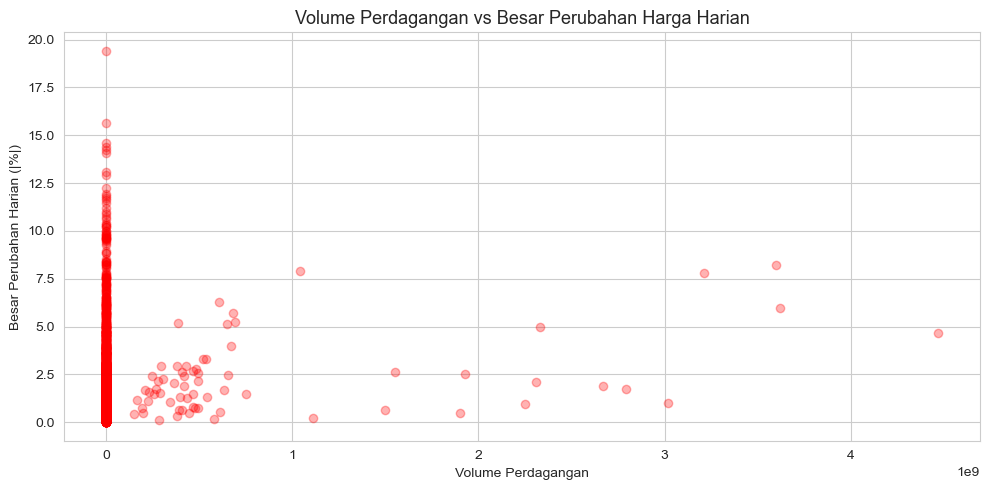

Koefisien korelasi volume vs besar perubahan: 0.066


In [16]:
# Menggunakan nilai absolut perubahan agar fokus pada BESAR perubahan (bukan arah)
data['Abs_Change'] = data['Change'].abs()

plt.figure(figsize=(10, 5))
plt.scatter(data['Volume'], data['Abs_Change'], alpha=0.3, color='#FF0000')
plt.title('Volume Perdagangan vs Besar Perubahan Harga Harian', fontsize=13)
plt.xlabel('Volume Perdagangan')
plt.ylabel('Besar Perubahan Harian (|%|)')
plt.tight_layout()
plt.show()

korelasi = data['Volume'].corr(data['Abs_Change'])
print('Koefisien korelasi volume vs besar perubahan: {:.3f}'.format(korelasi))

**Insight:** Nilai korelasi sangat kecil (mendekati 0), dan dari scatter plot tidak terlihat pola yang jelas. Artinya, **volume perdagangan tinggi tidak otomatis berarti perubahan harga yang besar**. Bagi client, hal ini berarti bahwa volume saja bukan indikator yang bisa dipercaya sepenuhnya untuk memprediksi seberapa besar harga akan bergerak dalam sehari.

### Statistik Deskriptif - Mengukur Volatilitas Harian
*Menjawab penjabaran masalah no.5: Seberapa besar volatilitas (risiko) harian Bitcoin?*

Bagian ini menggunakan central tendency (mean, median) dan measure of variance (standar deviasi, min, max, range) dari perubahan harga harian. Standar deviasi yang besar menunjukkan risiko/volatilitas yang tinggi.

In [17]:
# Statistik deskriptif perubahan harga harian
desc = data['Change'].describe()
print('Statistik Deskriptif Perubahan Harga Harian (%)')
print('-' * 45)
print('Rata-rata (mean)      : {:.3f}%'.format(desc['mean']))
print('Median                : {:.3f}%'.format(data['Change'].median()))
print('Standar Deviasi (std) : {:.3f}%'.format(desc['std']))
print('Minimum               : {:.3f}%'.format(desc['min']))
print('Maksimum              : {:.3f}%'.format(desc['max']))
print('Range (max - min)     : {:.3f}%'.format(desc['max'] - desc['min']))

Statistik Deskriptif Perubahan Harga Harian (%)
---------------------------------------------
Rata-rata (mean)      : 0.092%
Median                : -0.010%
Standar Deviasi (std) : 3.037%
Minimum               : -15.630%
Maksimum              : 19.410%
Range (max - min)     : 35.040%


In [18]:
# Bandingkan juga dengan standar deviasi (volatilitas) per tahun
volatilitas_tahun = data.groupby('Year')['Change'].std()
print('Volatilitas (standar deviasi perubahan harian) per tahun:')
print(volatilitas_tahun)

Volatilitas (standar deviasi perubahan harian) per tahun:
Year
2021   4.24
2022   3.35
2023   2.30
2024   2.78
2025   2.19
2026   2.62
Name: Change, dtype: float64


**Insight:** Rata-rata perubahan harian mendekati 0%, tetapi standar deviasinya cukup besar (beberapa persen per hari). Bahkan ada hari dengan perubahan ekstrem mencapai dua digit persen dalam sehari. Range antara perubahan terbesar dan terkecil sangat lebar. Semua ini menunjukkan bahwa **volatilitas harian Bitcoin tergolong tinggi**, sehingga client harus menyiapkan toleransi risiko yang besar dan tidak bergantung pada pergerakan harga jangka pendek.

### Visualisasi Pendukung Statistik Deskriptif - Box Plot Volatilitas Harian

Untuk menggambarkan secara visual sebaran (volatilitas) perubahan harga harian dengan menggunakan **box plot**. Box plot menampilkan median, kuartil (IQR), serta titik-titik outlier (hari dengan perubahan ekstrem) dalam satu gambar.

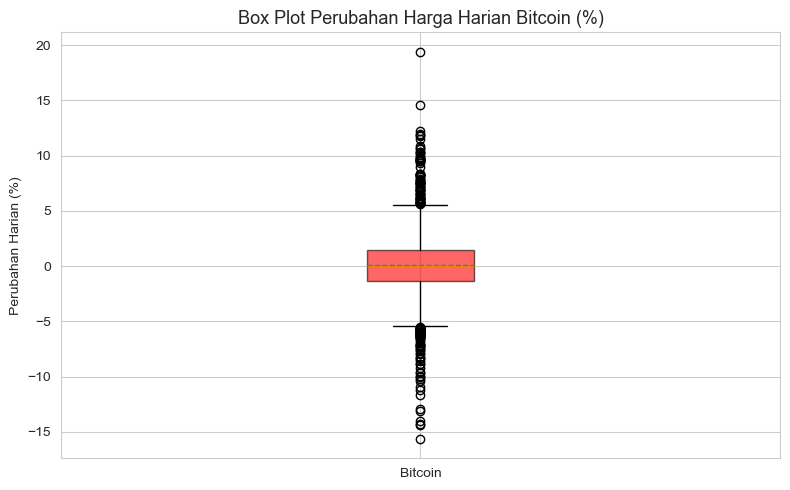

Q1 (kuartil bawah) : -1.33%
Median             : -0.01%
Q3 (kuartil atas)  : 1.46%
IQR (Q3 - Q1)      : 2.79%


In [19]:
plt.figure(figsize=(8, 5))
box = plt.boxplot(data['Change'], vert=True, patch_artist=True,
                  showmeans=True, meanline=True)
# Beri warna pada kotak
for patch in box['boxes']:
    patch.set_facecolor('#FF0000')
    patch.set_alpha(0.6)

plt.title('Box Plot Perubahan Harga Harian Bitcoin (%)', fontsize=13)
plt.ylabel('Perubahan Harian (%)')
plt.xticks([1], ['Bitcoin'])
plt.tight_layout()
plt.show()

# Tampilkan nilai-nilai kunci yang digambarkan box plot
Q1 = data['Change'].quantile(0.25)
Q3 = data['Change'].quantile(0.75)
IQR = Q3 - Q1
print('Q1 (kuartil bawah) : {:.2f}%'.format(Q1))
print('Median             : {:.2f}%'.format(data['Change'].median()))
print('Q3 (kuartil atas)  : {:.2f}%'.format(Q3))
print('IQR (Q3 - Q1)      : {:.2f}%'.format(IQR))

### Statistik Inferensial - Uji Beda Rata-rata (Two Sample Independent T-Test)
*Menjawab penjabaran masalah no.6: Apakah rata-rata perubahan harga harian tahun 2025 (bull market) berbeda signifikan dengan tahun 2022 (bear market)?*

Bagian ini akan **uji t dua sampel independen (independent two-sample t-test)** dengan tingkat signifikansi (alpha) = 0,05.

- H0 (hipotesis nol): Tidak ada perbedaan rata-rata perubahan harian antara tahun 2025 dan 2022.
- H1 (hipotesis alternatif): Ada perbedaan rata-rata perubahan harian antara tahun 2025 dan 2022.

In [20]:
# Ambil data perubahan harian untuk masing-masing tahun
change_2025 = data[data['Year'] == 2025]['Change']
change_2022 = data[data['Year'] == 2022]['Change']

print('Tahun 2025 -> jumlah hari: {}, rata-rata: {:.3f}%'.format(len(change_2025), change_2025.mean()))
print('Tahun 2022 -> jumlah hari: {}, rata-rata: {:.3f}%'.format(len(change_2022), change_2022.mean()))

# Lakukan uji t dua sampel independen
# equal_var=False (Welch's t-test) lebih aman karena varians kedua kelompok bisa berbeda
t_stat, p_value = stats.ttest_ind(change_2025, change_2022, equal_var=False)

print()
print('Hasil Uji T Dua Sampel Independen')
print('-' * 40)
print('t-statistic : {:.4f}'.format(t_stat))
print('p-value     : {:.4f}'.format(p_value))

Tahun 2025 -> jumlah hari: 365, rata-rata: 0.006%
Tahun 2022 -> jumlah hari: 365, rata-rata: -0.224%

Hasil Uji T Dua Sampel Independen
----------------------------------------
t-statistic : 1.0999
p-value     : 0.2718


In [21]:
# Ambil kesimpulan berdasarkan p-value
alpha = 0.05
if p_value < alpha:
    print('p-value ({:.4f}) < alpha ({})'.format(p_value, alpha))
    print('Kesimpulan: Ada perbedaan rata-rata perubahan harian yang signifikan secara statistik antara 2025 dan 2022.')
else:
    print('p-value ({:.4f}) >= alpha ({})'.format(p_value, alpha))

p-value (0.2718) >= alpha (0.05)


**Insight:** Hasil uji t menunjukkan perbandingan rata-rata perubahan harian antara tahun bull market (2025) dan bear market (2022). Keputusan diambil dengan membandingkan p-value dengan alpha 0,05 (lihat output sel di atas). Apapun hasilnya, ini memberikan gambaran objektif kepada client apakah perasaaan pasar bullish vs bearish benar-benar tercermin pada rata-rata perubahan harian, atau justru perbedaannya lebih banyak terletak pada arah tren jangka panjang dan tingkat volatilitas, bukan pada rata-rata perubahan harian.

### Visualisasi Statistik Inferensial - Line Chart Perbandingan 2022 vs 2025

Untuk memperkuat hasil uji statistik inferensial di atas, kita buat line chart yang membandingkan pergerakan harga harian Bitcoin pada tahun **2022 (bear market)** dan **2025 (bull market)**. Sumbu X memakai hari ke-berapa dalam tahun (1-365) agar kedua tahun bisa ditumpuk dan dibandingkan secara visual.

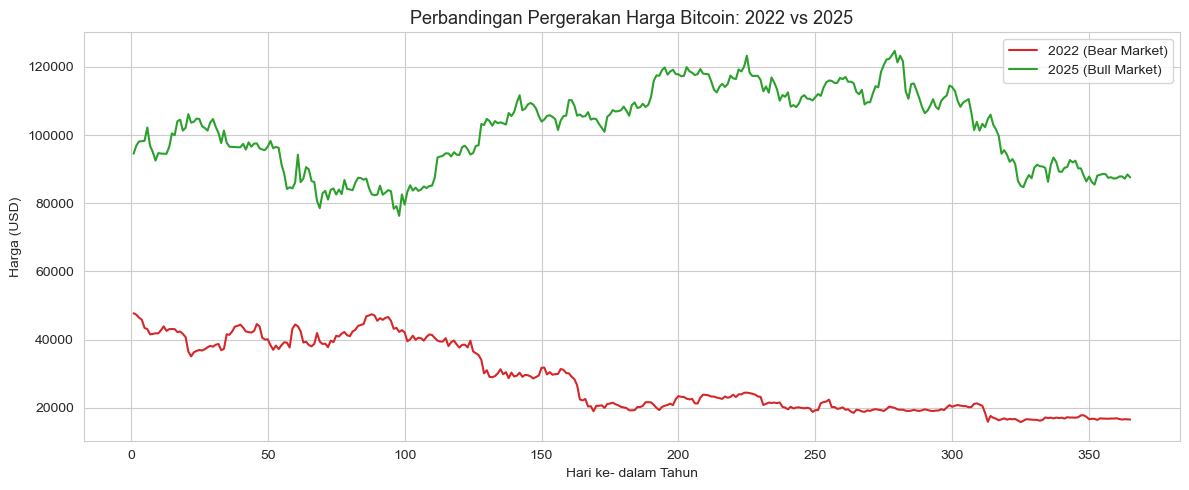

In [22]:
# Siapkan data dua tahun: 2022 dan 2025
df_2022 = data[data['Year'] == 2022].copy().sort_values('Date')
df_2025 = data[data['Year'] == 2025].copy().sort_values('Date')

# Buat kolom 'hari ke-' dalam tahun (day of year) agar bisa ditumpuk
df_2022['DayOfYear'] = df_2022['Date'].dt.dayofyear
df_2025['DayOfYear'] = df_2025['Date'].dt.dayofyear

plt.figure(figsize=(12, 5))
plt.plot(df_2022['DayOfYear'], df_2022['Price'], color='#d62728', label='2022 (Bear Market)')
plt.plot(df_2025['DayOfYear'], df_2025['Price'], color='#2ca02c', label='2025 (Bull Market)')
plt.title('Perbandingan Pergerakan Harga Bitcoin: 2022 vs 2025', fontsize=13)
plt.xlabel('Hari ke- dalam Tahun')
plt.ylabel('Harga (USD)')
plt.legend()
plt.tight_layout()
plt.show()

Insight: Line chart ini memperjelas hasil uji t. Secara arah tren, tahun 2025 (hijau) bergerak di level harga yang jauh lebih tinggi dibanding 2022 (merah) yang terus menurun. Namun, jika dilihat dari naik-turun harian-nya, kedua tahun sama-sama bergelombang. Inilah yang menjelaskan kenapa uji t pada rata-rata perubahan harian tidak signifikan: yang membedakan bull dan bear market adalah arah tren jangka panjang dan level harga, bukan rata-rata perubahan harian. Investor sebaiknya menilai kondisi pasar dari tren, bukan dari rata-rata gerakan harian.

## 6. Kesimpulan

Berdasarkan seluruh analisis dan perhitungan di atas, berikut benang merah dan rekomendasi untuk client (firma investasi):

1. **Tren jangka panjang positif tapi sangat fluktuatif.** Harga Bitcoin mengalami siklus naik-turun yang ekstrem, baik bull maupun bear market. Rata-rata harga tahunan tertinggi terjadi pada tahun 2025.

2. **Volatilitas harian tinggi.** Rata-rata perubahan harian mendekati 0%, namun standar deviasinya besar dengan beberapa hari berperubahan ekstrem. Ini menegaskan Bitcoin sebagai aset berisiko tinggi.

3. **Perubahan harian bersifat acak dan sulit diprediksi dari volume.** Distribusi perubahan harian berpusat di nol dengan ekor lebar, dan volume perdagangan hampir tidak berkorelasi dengan besarnya perubahan harga. Volume bukan indikator yang bisa diandalkan untuk memprediksi pergerakan harga harian.

4. **Perbedaan bull vs bear lebih pada tren dan volatilitas, bukan rata-rata harian.** Uji statistik membantu client agar tidak terjebak asumsi bahwa pasar bullish selalu berarti rata-rata kenaikan harian yang jauh lebih besar.

### Rekomendasi
- Terapkan strategi jangka panjang (buy and hold) daripada melakukan trading harian, karena pergerakan harian sulit diprediksi.
- Gunakan manajemen risiko ketat, misalnya alokasi dana terbatas, diversifikasi mengingat tingkat volatilitas yang tinggi.
- Jangan mengandalkan volume perdagangan sebagai sinyal tunggal untuk memprediksi pergerakan harga.
- Fokuskan analisis pada tren dan tingkat risiko (volatilitas), bukan hanya rata-rata perubahan harian. 


